# Actividad - Proyecto práctico


> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar entregar el trabajo en la presente notebook.
*   Alumno 1: Williams
*   Alumno 2: Ángel
*   Alumno 3: María Elena
*   Alumno 4: Marina






---
## **PARTE 1** - Instalación y requisitos previos

> Las prácticas han sido preparadas para poder realizarse en el entorno de trabajo de Google Colab. Sin embargo, esta plataforma presenta ciertas incompatibilidades a la hora de visualizar la renderización en gym. Por ello, para obtener estas visualizaciones, se deberá trasladar el entorno de trabajo a local. Por ello, el presente dosier presenta instrucciones para poder trabajar en ambos entornos. Siga los siguientes pasos para un correcto funcionamiento:
1.   **LOCAL:** Preparar el enviroment, siguiendo las intrucciones detalladas en la sección *1.1.Preparar enviroment*.
2.  **AMBOS:** Modificar las variables "mount" y "drive_mount" a la carpeta de trabajo en drive en el caso de estar en Colab, y ejecturar la celda *1.2.Localizar entorno de trabajo*.
3. **COLAB:** se deberá ejecutar las celdas correspondientes al montaje de la carpeta de trabajo en Drive. Esta corresponde a la sección *1.3.Montar carpeta de datos local*.
4.  **AMBOS:** Instalar las librerías necesarias, siguiendo la sección *1.4.Instalar librerías necesarias*.


---
### 1.1. Preparar enviroment (solo local)



> Para preparar el entorno de trabajo en local, se han seguido los siguientes pasos:
1. En Windows, puede ser necesario instalar las C++ Build Tools. Para ello, siga los siguientes pasos. Alternativamente puedes utilizar WSL2: https://towardsdatascience.com/how-to-install-openai-gym-in-a-windows-environment-338969e24d30.
2. Instalar Anaconda
3. Siguiendo el código que se presenta comentado en la próxima celda: Crear un enviroment, cambiar la ruta de trabajo, e instalar librerías básicas.


```
conda create --name miar_rl python=3.8
conda activate miar_rl
cd "PATH_TO_FOLDER"
conda install git
pip install jupyter
```


4. Abrir la notebook con *jupyter-notebook*.



```
jupyter-notebook
```


---
### 1.2. Localizar entorno de trabajo: Google colab o local

In [2]:
mount='/content/gdrive'
drive_root = mount + "/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints"

try:
  from google.colab import drive
  IN_COLAB=True
except:
  IN_COLAB=False

---
### 1.3. Montar carpeta de datos local (solo Colab)

In [3]:
# Montamos Drive y fijamos el directorio de trabajo a una carpeta DENTRO de
# Drive (drive_root). Esto es importante para entrenamientos largos (varias
# horas, dejados corriendo sin supervisión): si el runtime de Colab se
# desconecta o se recicla, todo lo que esté solo en el disco local del
# runtime (/content/...) se pierde para siempre. Drive, en cambio, persiste
# independientemente de lo que le pase al runtime.
#
# Nota: el propio mount de Drive puede a veces tardar o pedir reautorización
# en VSCode; si la celda se queda colgada en drive.mount(), revisa si apareció
# una ventana/pestaña de autorización de Google que necesite tu confirmación.
import os

if IN_COLAB:
    print("We're running Colab")
    drive.mount(mount)
    os.makedirs(drive_root, exist_ok=True)
    print("\nColab: Changing directory to", drive_root)
    os.chdir(drive_root)
else:
    print("No estamos en Colab (IN_COLAB=False); se usará el directorio actual del kernel.")

WORK_DIR = os.getcwd()
print("\nDirectorio de trabajo actual:", WORK_DIR)
print("Archivos en el directorio:")
print(os.listdir(WORK_DIR))

# Carpetas de salida, una por propuesta, directamente dentro de drive_root
# (.../VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/). Los checkpoints
# intermedios (ModelIntervalCheckpoint) y los logs se escriben aquí durante
# el entrenamiento, así que sobreviven a una desconexión del runtime.
RESULTS_DIR = WORK_DIR
WEIGHTS_DIR_P1 = os.path.join(RESULTS_DIR, 'p1_eps_fijo')
WEIGHTS_DIR_P2 = os.path.join(RESULTS_DIR, 'p2_annealed')
WEIGHTS_DIR_P3 = os.path.join(RESULTS_DIR, 'p3_boltzmann')
WEIGHTS_DIR_P4 = os.path.join(RESULTS_DIR, 'p4_double_dqn')
WEIGHTS_DIR_P5 = os.path.join(RESULTS_DIR, 'p5_dueling_dqn')
WEIGHTS_DIR_P6 = os.path.join(RESULTS_DIR, 'p6_double_dueling')
WEIGHTS_DIR_P7 = os.path.join(RESULTS_DIR, 'p7_double_dqn_annealed')
WEIGHTS_DIR_P8 = os.path.join(RESULTS_DIR, 'p8_dueling_dqn_annealed')

for d in [RESULTS_DIR, WEIGHTS_DIR_P1, WEIGHTS_DIR_P2, WEIGHTS_DIR_P3,
          WEIGHTS_DIR_P4, WEIGHTS_DIR_P5, WEIGHTS_DIR_P6, WEIGHTS_DIR_P7, WEIGHTS_DIR_P8]:
    os.makedirs(d, exist_ok=True)

print("\nCarpetas de checkpoints preparadas (en Drive):")
print(" -", WEIGHTS_DIR_P1)
print(" -", WEIGHTS_DIR_P2)
print(" -", WEIGHTS_DIR_P3)
print(" -", WEIGHTS_DIR_P4)
print(" -", WEIGHTS_DIR_P5)
print(" -", WEIGHTS_DIR_P6)
print(" -", WEIGHTS_DIR_P7)
print(" -", WEIGHTS_DIR_P8)

We're running Colab
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

Colab: Changing directory to /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints

Directorio de trabajo actual: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints
Archivos en el directorio:
['p1_eps_fijo', 'p2_annealed', 'p3_boltzmann', 'p4_double_dqn', 'p5_dueling_dqn', 'p6_double_dueling', 'p7_double_dqn_annealed', 'p8_dueling_dqn_annealed']

Carpetas de checkpoints preparadas (en Drive):
 - /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p1_eps_fijo
 - /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p2_annealed
 - /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p3_boltzmann
 - /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p4_double_dqn
 - /content/gdrive/My Drive/VIU_

---
### 1.4. Instalar librerías necesarias

In [5]:
if IN_COLAB:
  %pip install tensorflow
  %pip install tf-keras
  # %pip install tensorflow==2.18.0
  # %pip install tf-keras==2.18.0
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install keras-rl2==1.0.5
  %pip install --upgrade ml_dtypes
else:
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install pyglet==1.5.0
  %pip install h5py==3.1.0
  %pip install Pillow==9.5.0
  %pip install keras-rl2==1.0.5
  %pip install Keras==2.2.4
  %pip install tensorflow==2.5.3
  %pip install torch==2.0.1
  %pip install agents==1.4.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 62.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.5 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.17.3-py3-none-any.whl size=1654617 sha256=430a5e739c6ad171ad39f72c282d080907c25e0ad3fb5f708ca48af1b0ff1dfe
  Stored in directory: /root/.cache/pip/wheels/99/7e/03/69cdeb432380e05bc9a56ff68451d8063e41aa06db508f4be5
Successfully built gym
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.2
    Uninstalling cloudpickle-3.1.2:
      Successfully uninstalled cloudpickle-3.1.2
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask 2026.6.0 requires cloudpickle>=

  Cloning https://github.com/Kojoley/atari-py.git to /tmp/pip-req-build-holnyodz
  Running command git clone --filter=blob:none --quiet https://github.com/Kojoley/atari-py.git /tmp/pip-req-build-holnyodz
  Resolved https://github.com/Kojoley/atari-py.git to commit 86a1e05c0a95e9e6233c3a413521fdb34ca8a089
  Preparing metadata (setup.py) ... done
  Created wheel for atari-py: filename=atari_py-1.2.2-cp312-cp312-linux_x86_64.whl size=4739147 sha256=d6f4f99ea54a515f31ce2d375b3049db4d4739fc8a7d0fa15c93d653cb67c077
  Stored in directory: /tmp/pip-ephem-wheel-cache-1_h0sq0f/wheels/cb/1f/56/35b393898f74ae3d978063738e8eeb4b3d7357d0d7eeec6b9f
Successfully built atari-py
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.1/52.1 kB 5.1 MB/s eta 0:00:00


---
## **PARTE 2**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondien de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
## **PARTE 3**. Desarrollo y preguntas

#### Importar librerías

In [6]:
#Comprobamos que se carga la versión esperada de TF y detecta la GPU
import os

os.environ['TF_USE_LEGACY_KERAS']="1"

import tensorflow.keras as tf
import tensorflow as tf1

from keras import __version__
tf.__version__ = __version__

print(tf1.__version__)
print(tf1.config.list_physical_devices('GPU'))
print(tf1.config.list_logical_devices('GPU'))

2.20.0
[]
[]


In [7]:
from __future__ import division

from PIL import Image
import numpy as np
import gym

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Convolution2D, Permute

if IN_COLAB:
  from tensorflow.keras.optimizers.legacy import Adam
else:
  from tensorflow.keras.optimizers import Adam

import tensorflow.keras.backend as K

from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, BoltzmannQPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import FileLogger, ModelIntervalCheckpoint

In [ ]:
# ----------------------------------------------------------------------
# FIX NECESARIO solo si vas a usar Dueling DQN (enable_dueling_network=True,
# ver Propuesta 4 más abajo): keras-rl2 construye la cabeza dueling con una
# capa Lambda que contiene una función lambda de Python. Al compilar el
# agente, keras-rl2 necesita clonar el modelo (para crear la red objetivo),
# y las versiones modernas de tf_keras bloquean por seguridad la
# deserialización de capas Lambda con lambdas de Python, salvo que se
# habilite explícitamente. Esto no afecta a Double DQN por sí solo, solo
# cuando se combina con Dueling.
import tf_keras
tf_keras.__internal__.enable_unsafe_deserialization()
# ----------------------------------------------------------------------

#### Configuración base

In [ ]:
INPUT_SHAPE = (84, 84)
WINDOW_LENGTH = 4

env_name = 'Enduro-v0'
env = gym.make(env_name)

np.random.seed(123)
env.seed(123)
nb_actions = env.action_space.n

print("Entorno:", env_name)
print("Número de acciones disponibles:", nb_actions)
print("Significado de las acciones:", env.unwrapped.get_action_meanings())
print("Formato de las observaciones:", env.observation_space)

In [11]:
class AtariProcessor(Processor):

    def process_observation(self, observation):
        assert observation.ndim == 3  # (height, width, channel)
        img = Image.fromarray(observation)
        img = img.resize(INPUT_SHAPE).convert('L')
        processed_observation = np.array(img)
        assert processed_observation.shape == INPUT_SHAPE
        return processed_observation.astype('uint8')

    def process_state_batch(self, batch):
        processed_batch = batch.astype('float32') / 255.
        return processed_batch

    def process_reward(self, reward):
        return float(np.clip(reward, -1., 1.))


1. Implementación de la red neuronal

In [ ]:
input_shape = (WINDOW_LENGTH,) + INPUT_SHAPE


def build_model(nb_actions, input_shape):
    model = Sequential()
    if K.image_data_format() == 'channels_last':
        # (width, height, channels)
        model.add(Permute((2, 3, 1), input_shape=input_shape))
    elif K.image_data_format() == 'channels_first':
        # (channels, width, height)
        model.add(Permute((1, 2, 3), input_shape=input_shape))
    else:
        raise RuntimeError('Unknown image_dim_ordering.')

    model.add(Convolution2D(32, (8, 8), strides=(4, 4)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (4, 4), strides=(2, 2)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (3, 3), strides=(1, 1)))
    model.add(Activation('relu'))
    model.add(Flatten())
    model.add(Dense(512))
    model.add(Activation('relu'))
    model.add(Dense(nb_actions))
    model.add(Activation('linear'))
    return model


model = build_model(nb_actions, input_shape)
print(model.summary()) 

2. Implementación de la solución DQN

In [ ]:
NB_STEPS_TRAIN = 2000000  # ajustar según tiempo disponible / checkpoints
NB_EPISODES = 10

In [ ]:
def load_weights_for_test(agent, proposal_id, weights_dir):
    """Carga el último checkpoint disponible para poder hacer test."""
    ckpt, step = find_latest_checkpoint(weights_dir, f'dqn_Enduro-v0_{proposal_id}')
    if ckpt is not None:
        agent.load_weights(ckpt)
        print(f"[{proposal_id}] Pesos cargados para test desde: {ckpt}  (step {step})")
    else:
        print(f"[{proposal_id}] ⚠️  Sin checkpoints. Entrena primero.")

In [ ]:
def test_proposal(proposal_id, agents_registry, nb_episodes=NB_EPISODES):
    """
    Evalúa una propuesta cargando automáticamente su último checkpoint.
    agents_registry: dict con la info de cada propuesta (dir, prefix, agente).
    """
    if proposal_id not in agents_registry:
        print(f"'{proposal_id}' no está en el registro. Opciones: {list(agents_registry.keys())}")
        return

    info = agents_registry[proposal_id]

    if info['agent'] is None:
        print(f"[{proposal_id}] El agente no está en memoria todavía. Ejecuta primero su celda de construcción.")
        return

    weights_filename, last_step = find_latest_checkpoint(info['dir'], info['prefix'])

    if weights_filename is None:
        print(f"[{proposal_id}] ⚠️  Sin checkpoints en {info['dir']}. Entrena primero.")
        return

    print(f"[{proposal_id}] Cargando pesos desde: {weights_filename}  (step {last_step})")
    info['agent'].load_weights(weights_filename)
    test_history = info['agent'].test(env, nb_episodes=nb_episodes, visualize=False)

    mean_reward = np.mean(test_history.history['episode_reward'])
    std_reward  = np.std(test_history.history['episode_reward'])
    print(f"[{proposal_id}] Recompensa media en {nb_episodes} episodios: {mean_reward:.2f} (+/- {std_reward:.2f})")
    return test_history

In [ ]:
# ── Registro central de propuestas ────────────────────────────────────
AGENTS_REGISTRY = {
    'p1': {'dir': WEIGHTS_DIR_P1, 'prefix': 'dqn_Enduro-v0_p1', 'agent': None},
    'p2': {'dir': WEIGHTS_DIR_P2, 'prefix': 'dqn_Enduro-v0_p2', 'agent': None},
    'p3': {'dir': WEIGHTS_DIR_P3, 'prefix': 'dqn_Enduro-v0_p3', 'agent': None},
    'p4': {'dir': WEIGHTS_DIR_P4, 'prefix': 'dqn_Enduro-v0_p4', 'agent': None},
    'p5': {'dir': WEIGHTS_DIR_P5, 'prefix': 'dqn_Enduro-v0_p5', 'agent': None},
    'p6': {'dir': WEIGHTS_DIR_P6, 'prefix': 'dqn_Enduro-v0_p6', 'agent': None},
    'p7': {'dir': WEIGHTS_DIR_P7, 'prefix': 'dqn_Enduro-v0_p7', 'agent': None},
    'p8': {'dir': WEIGHTS_DIR_P8, 'prefix': 'dqn_Enduro-v0_p8', 'agent': None},
}

In [ ]:
def build_dqn_agent(model, nb_actions, memory, processor, policy,
                     nb_steps_warmup, target_model_update,
                     train_interval=4, gamma=.99,
                     enable_double_dqn=False, enable_dueling_network=False,
                     dueling_type='avg'):
    dqn = DQNAgent(model=model, nb_actions=nb_actions, policy=policy,
                   memory=memory, processor=processor,
                   nb_steps_warmup=nb_steps_warmup, gamma=gamma,
                   target_model_update=target_model_update,
                   train_interval=train_interval,
                   enable_double_dqn=enable_double_dqn,
                   enable_dueling_network=enable_dueling_network,
                   dueling_type=dueling_type)
    dqn.compile(Adam(learning_rate=.00025), metrics=['mae'])
    return dqn

In [ ]:

class ResumableModelIntervalCheckpoint(ModelIntervalCheckpoint):
    def __init__(self, filepath, interval, step_offset=0, verbose=0):
        super().__init__(filepath, interval, verbose=verbose)
        self.step_offset = step_offset

    def on_step_end(self, step, logs={}):
        self.total_steps += 1
        if self.total_steps % self.interval != 0:
            return
        absolute_step = self.step_offset + self.total_steps
        filepath = self.filepath.format(step=absolute_step, **logs)
        if self.verbose > 0:
            print(f'Step {absolute_step}: guardando modelo en {filepath}')
        self.model.save_weights(filepath, overwrite=True)


def find_latest_checkpoint(weights_dir, prefix):
    """
    Busca en weights_dir el checkpoint con el step más alto que siga el
    patrón '{prefix}_weights_{step}.h5f.index', y devuelve una tupla
    (ruta_sin_extension, step) o (None, 0) si no hay ninguno.
    Útil para retomar automáticamente "desde el último punto guardado".
    """
    import re
    import glob
    pattern = os.path.join(weights_dir, f'{prefix}_weights_*.h5f.index')
    candidates = glob.glob(pattern)
    best_step = -1
    best_path = None
    for c in candidates:
        m = re.search(r'_weights_(\d+)\.h5f\.index$', c)
        if m:
            step = int(m.group(1))
            if step > best_step:
                best_step = step
                best_path = c[:-len('.index')]
    if best_path is None:
        return None, 0
    return best_path, best_step
# ----------------------------------------------------------------------

In [ ]:
def read_last_annealed_value_from_log(log_path, attr='eps'):
    """
    Lee el log JSON generado por FileLogger y devuelve el último valor
    registrado de la métrica 'mean_{attr}' (mean_eps o mean_tau), junto con
    el último nb_steps registrado en ese mismo punto.
    Devuelve (None, 0) si el log no existe o no contiene esa métrica
    todavía (p. ej. si el entrenamiento se interrumpió antes del primer
    episodio completo).
    """
    import json
    import os

    metric_key = f'mean_{attr}'
    if not os.path.exists(log_path):
        return None, 0

    with open(log_path, 'r') as f:
        data = json.load(f)

    if metric_key not in data or not data[metric_key]:
        return None, 0

    last_value = data[metric_key][-1]
    last_step = data['nb_steps'][-1] if 'nb_steps' in data and data['nb_steps'] else 0
    return last_value, last_step


class OffsetLinearAnnealedPolicy(LinearAnnealedPolicy):
    """
    Igual que LinearAnnealedPolicy, pero permite indicar un step_offset
    para que el cálculo del valor (eps o tau) se haga con el step ABSOLUTO
    real (offset + step de esta tanda), en lugar de reiniciar el annealing
    desde 0 cada vez que se reanuda el entrenamiento.

    Internamente sobreescribe get_current_value() para usar
    (self.step_offset + self.agent.step) en vez de solo self.agent.step.
    """
    def __init__(self, inner_policy, attr, value_max, value_min, value_test,
                 nb_steps, step_offset=0):
        super().__init__(inner_policy, attr, value_max, value_min, value_test, nb_steps)
        self.step_offset = step_offset

    def get_current_value(self):
        if self.agent.training:
            a = -float(self.value_max - self.value_min) / float(self.nb_steps)
            b = float(self.value_max)
            absolute_step = self.step_offset + self.agent.step
            value = max(self.value_min, a * float(absolute_step) + b)
        else:
            value = self.value_test
        return value

#### **Propuesta 4 — Double DQN**

##### Policy P4

In [ ]:
# --- Reanudación opcional (ver explicación detallada en la Propuesta 1) ---
RESUME_FROM_P4 = None
STEP_OFFSET_P4 = 0
RESUME_FROM_P4, STEP_OFFSET_P4 = find_latest_checkpoint(WEIGHTS_DIR_P4, 'dqn_Enduro-v0_p4')

model_p4 = build_model(nb_actions, input_shape)
memory_p4 = SequentialMemory(limit=1000000, window_length=WINDOW_LENGTH)

policy_p4 = EpsGreedyQPolicy(eps=0.2)

dqn_p4 = build_dqn_agent(
    model=model_p4, nb_actions=nb_actions, memory=memory_p4,
    processor=AtariProcessor(), policy=policy_p4,
    nb_steps_warmup=50000, target_model_update=10000,
    enable_double_dqn=True, enable_dueling_network=False
)

load_weights_for_test(dqn_p4, 'p4', WEIGHTS_DIR_P4)

AGENTS_REGISTRY['p4']['agent'] = dqn_p4   # ← se registra aquí

[p4] Pesos cargados para test desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p4_double_dqn/dqn_Enduro-v0_p4_weights_800000.h5f  (step 800000)


##### P4 Entrenamiento

In [ ]:
# Usar TRUE para entrenar, o FALSE para saltar el entrenamiento 
RUN_TRAINING_P4 = False          # <── GUARDIA PRINCIPAL

if RUN_TRAINING_P4:

    if RESUME_FROM_P4 is not None:
        print(f"Reanudando Propuesta 4 desde el checkpoint: {RESUME_FROM_P4}")
        dqn_p4.load_weights(RESUME_FROM_P4)
        NB_STEPS_REMAINING_P4 = max(0, NB_STEPS_TRAIN - STEP_OFFSET_P4)
    else:
        NB_STEPS_REMAINING_P4 = NB_STEPS_TRAIN

    weights_filename_p4 = os.path.join(WEIGHTS_DIR_P4, 'dqn_{}_p4_double_dqn_weights.h5f'.format(env_name))
    checkpoint_filename_p4 = os.path.join(WEIGHTS_DIR_P4, 'dqn_' + env_name + '_p4_weights_{step}.h5f')
    log_filename_p4 = os.path.join(WEIGHTS_DIR_P4, 'dqn_{}_p4_log.json'.format(env_name))

    callbacks_p4 = [ResumableModelIntervalCheckpoint(checkpoint_filename_p4, interval=100000,
                                                    step_offset=STEP_OFFSET_P4)]
    callbacks_p4 += [FileLogger(log_filename_p4, interval=1000)]

    history_p4 = dqn_p4.fit(env, callbacks=callbacks_p4, nb_steps=NB_STEPS_REMAINING_P4,
                            log_interval=10000, visualize=False)

    dqn_p4.save_weights(weights_filename_p4, overwrite=True)
    print("Pesos finales de la Propuesta 4 guardados en Drive:", weights_filename_p4)
    print("Contenido de la carpeta:", os.listdir(WEIGHTS_DIR_P4))

else:
    print("[P4] Entrenamiento omitido (RUN_TRAINING_P4=False).")

[P4] Entrenamiento omitido (RUN_TRAINING_P4=False).


In [ ]:
PROPUESTA_A_EVALUAR = 'p4'   # ← único parámetro a tocar

test_history = test_proposal(PROPUESTA_A_EVALUAR, AGENTS_REGISTRY)

[p4] Cargando pesos desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p4_double_dqn/dqn_Enduro-v0_p4_weights_800000.h5f  (step 800000)
Testing for 10 episodes ...
Episode 1: reward: 275.000, steps: 8858
Episode 2: reward: 158.000, steps: 4446
Episode 3: reward: 156.000, steps: 4478
Episode 4: reward: 316.000, steps: 8893
Episode 5: reward: 132.000, steps: 4421
Episode 6: reward: 197.000, steps: 4452
Episode 7: reward: 285.000, steps: 8801
Episode 8: reward: 195.000, steps: 4452
Episode 9: reward: 192.000, steps: 4463
Episode 10: reward: 284.000, steps: 8883
[p4] Recompensa media en 10 episodios: 219.00 (+/- 61.79)


#### **Propuesta 7: Double DQN con annealing de epsilon**

##### P7 Policy

In [ ]:
# ----------------------------------------------------------------------
# PROPUESTA 7: Double DQN con annealing de epsilon
# Double DQN: usa la red principal para ELEGIR la acción y la red objetivo para EVALUARLA
# ----------------------------------------------------------------------

# --- Reanudación ---
RESUME_FROM_P7 = None
STEP_OFFSET_P7 = 0
RESUME_FROM_P7, STEP_OFFSET_P7 = find_latest_checkpoint(WEIGHTS_DIR_P7, 'dqn_Enduro-v0_p7')

model_p7 = build_model(nb_actions, input_shape)
memory_p7 = SequentialMemory(limit=1000000, window_length=WINDOW_LENGTH)

# Definimos las rutas antes de construir la policy (necesitamos el log para
# recuperar el último epsilon real si estamos reanudando)
weights_filename_p7 = os.path.join(WEIGHTS_DIR_P7, 'dqn_{}_p7_weights.h5f'.format(env_name))
checkpoint_filename_p7 = os.path.join(WEIGHTS_DIR_P7, 'dqn_' + env_name + '_p7_weights_{step}.h5f')
log_filename_p7 = os.path.join(WEIGHTS_DIR_P7, 'dqn_{}_p7_log.json'.format(env_name))

# Annealing de epsilon 1.0 -> 0.1 en 300k steps (igual que en el paper de
# referencia). Al reanudar, usamos OffsetLinearAnnealedPolicy para que el
# eps continúe desde donde realmente se quedó en vez de reiniciarse a 1.0.
# Si ya se superaron los 1.2m steps, eps arrancará directamente en 0.1.
_eps_log_value, _eps_log_step = read_last_annealed_value_from_log(log_filename_p7, attr='eps')
if _eps_log_value is not None:
    print(f"Reanudando annealing de epsilon: último valor = {_eps_log_value:.4f} (step {_eps_log_step})")
    _eps_step_offset_p7 = _eps_log_step
else:
    # Sin log previo: calculamos el offset a partir del step del checkpoint
    _eps_step_offset_p7 = STEP_OFFSET_P7

policy_p7 = OffsetLinearAnnealedPolicy(
    EpsGreedyQPolicy(), attr='eps',
    value_max=1., value_min=.1, value_test=.05,
    nb_steps=1200000,
    step_offset=_eps_step_offset_p7  # continúa el annealing desde el punto real
)

dqn_p7 = build_dqn_agent(
    model=model_p7, nb_actions=nb_actions, memory=memory_p7,
    processor=AtariProcessor(), policy=policy_p7,
    nb_steps_warmup=50000, target_model_update=10000,
    enable_double_dqn=True, enable_dueling_network=False
)

load_weights_for_test(dqn_p7, 'p7', WEIGHTS_DIR_P7)

AGENTS_REGISTRY['p7']['agent'] = dqn_p7   # ← se registra aquí

Reanudando annealing de epsilon: último valor = nan (step 31054)
[p7] Pesos cargados para test desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p7_double_dqn_annealed/dqn_Enduro-v0_p7_weights_400000.h5f  (step 400000)


##### P7 Entrenamiento

In [ ]:
# Usar TRUE para entrenar, o FALSE para saltar el entrenamiento 
RUN_TRAINING_P7 = False          # <── GUARDIA PRINCIPAL

if RUN_TRAINING_P7:

    if RESUME_FROM_P7 is not None:
        print(f"Reanudando Propuesta 7 desde: {RESUME_FROM_P7}")
        dqn_p7.load_weights(RESUME_FROM_P7)
        NB_STEPS_REMAINING_P7 = max(0, NB_STEPS_TRAIN - STEP_OFFSET_P7)
    else:
        NB_STEPS_REMAINING_P7 = NB_STEPS_TRAIN

    callbacks_p7 = [ResumableModelIntervalCheckpoint(checkpoint_filename_p7, interval=100000,
                                                    step_offset=STEP_OFFSET_P7)]
    callbacks_p7 += [FileLogger(log_filename_p7, interval=1000)]

    history_p7 = dqn_p7.fit(env, callbacks=callbacks_p7, nb_steps=NB_STEPS_REMAINING_P7,
                            log_interval=10000, visualize=False)

    dqn_p7.save_weights(weights_filename_p7, overwrite=True)
    print("Pesos finales de la Propuesta 7 guardados:", weights_filename_p7)
    print("Contenido de la carpeta:", os.listdir(WEIGHTS_DIR_P7))

else:
    print("[P7] Entrenamiento omitido (RUN_TRAINING_P7=False).")

Reanudando Propuesta 7 desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p7_double_dqn_annealed/dqn_Enduro-v0_p7_weights_400000.h5f
Training for 800000 steps ...
Interval 1 (0 steps performed)
10000/10000 [==============================] - 49s 5ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 47s 5ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 47s 5ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 49s 5ms/step - reward: 0.0000e+00
3 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 5 (40000 steps performed)
10000/10000 [================

##### P7 Testeo

In [ ]:
PROPUESTA_A_EVALUAR = 'p7'   # ← único parámetro a tocar

test_history = test_proposal(PROPUESTA_A_EVALUAR, AGENTS_REGISTRY)

[p7] Cargando pesos desde: /content/gdrive/My Drive/VIU_Apr_por_Refuerzo_Grupo_17_2025_2026/checkpoints/p7_double_dqn_annealed/dqn_Enduro-v0_p7_weights_400000.h5f  (step 400000)
Testing for 10 episodes ...
Episode 1: reward: 0.000, steps: 4425
Episode 2: reward: 0.000, steps: 4436
Episode 3: reward: 0.000, steps: 4433
Episode 4: reward: 0.000, steps: 4432
Episode 5: reward: 0.000, steps: 4405
Episode 6: reward: 0.000, steps: 4443
Episode 7: reward: 0.000, steps: 4406
Episode 8: reward: 0.000, steps: 4439
Episode 9: reward: 0.000, steps: 4433
Episode 10: reward: 0.000, steps: 4435
[p7] Recompensa media en 10 episodios: 0.00 (+/- 0.00)


3. Justificación de los parámetros seleccionados y de los resultados obtenidos

---

In [4]:
# ----------------------------------------------------------------------
# PARTE 3: Carga de logs de entrenamiento para comparar las 3 propuestas
# ----------------------------------------------------------------------
import json
import matplotlib.pyplot as plt


def load_log(filename):
    with open(filename, 'r') as f:
        data = json.load(f)
    return data


log_p1 = load_log('p1_eps_fijo/dqn_Enduro-v0_p1_log.json')
log_p2 = load_log('p2_annealed/dqn_Enduro-v0_p2_log.json')
log_p3 = load_log('p3_boltzmann/dqn_Enduro-v0_p3_log.json')
log_p4 = load_log('p4_double_dqn/dqn_Enduro-v0_p4_log.json')
log_p5 = load_log('p5_dueling_dqn/dqn_Enduro-v0_p5_log.json')
log_p6 = load_log('p6_double_dueling/dqn_Enduro-v0_p6_log.json')
log_p7 = load_log('p7_double_dqn_annealed/dqn_Enduro-v0_p7_log.json')
log_p8 = load_log('p8_dueling_dqn_annealed/dqn_Enduro-v0_p8_log.json')

logs = {
    'Propuesta 1 (EpsGreedy fijo)': log_p1,
    'Propuesta 2 (Annealed EpsGreedy)': log_p2,
    'Propuesta 3 (Boltzmann)': log_p3,
    'Propuesta 4 (Double DQN)': log_p4,
    'Propuesta 5 (Dueling DQN)': log_p5,
    'Propuesta 6 (Double Dueling)': log_p6,
    'Propuesta 7 (Double DQN + Offset Annealing)': log_p7,
    'Propuesta 8 (Dueling DQN + Offset Annealing)': log_p8,
}

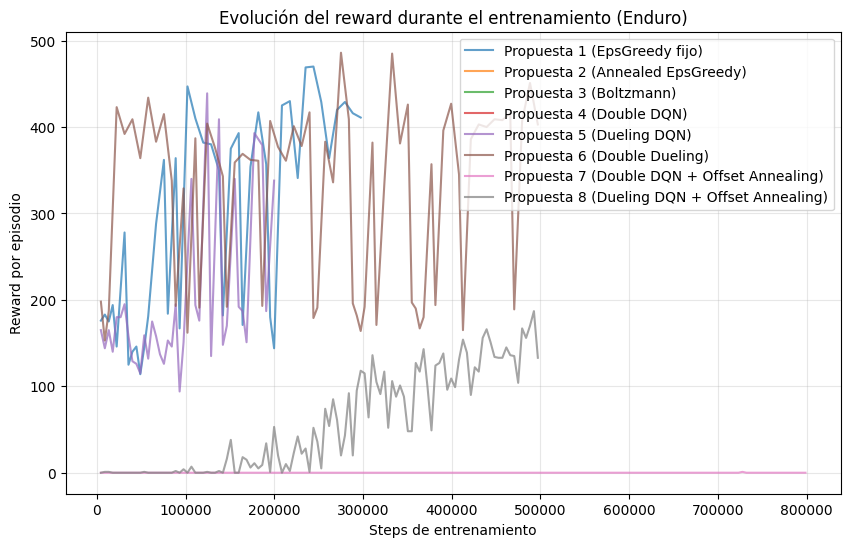

In [11]:
# Gráfica 1: evolución de la recompensa media por episodio durante el entrenamiento
plt.figure(figsize=(10, 6))
for label, log in logs.items():
    plt.plot(log['nb_steps'], log['episode_reward'], label=label, alpha=0.7)
plt.xlabel('Steps de entrenamiento')
plt.ylabel('Reward por episodio')
plt.title('Evolución del reward durante el entrenamiento (Enduro)')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('evolucion_recompensa.pdf')
plt.show()

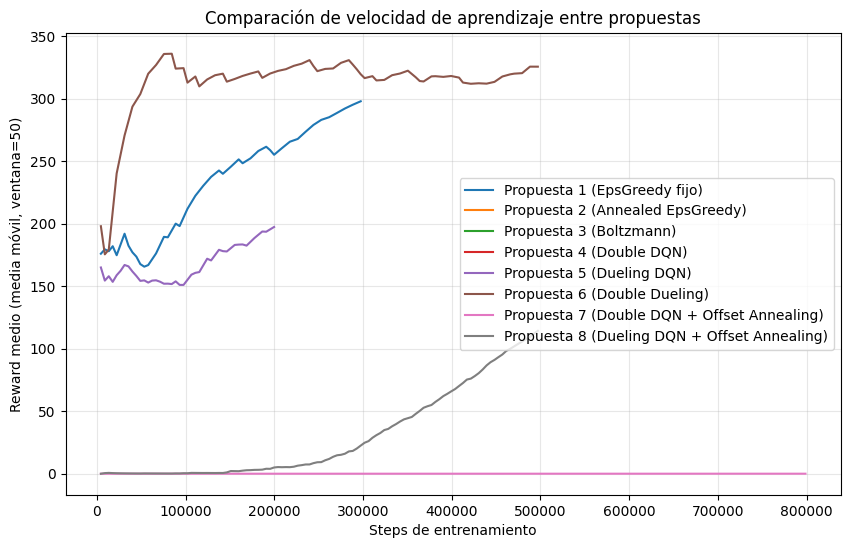

In [12]:
# Gráfica 2: media móvil del reward para suavizar la varianza episodio a episodio
import pandas as pd

plt.figure(figsize=(10, 6))
WINDOW = 50
for label, log in logs.items():
    rewards = pd.Series(log['episode_reward'])
    rolling = rewards.rolling(WINDOW, min_periods=1).mean()
    plt.plot(log['nb_steps'], rolling, label=label)
plt.xlabel('Steps de entrenamiento')
plt.ylabel(f'Reward medio (media móvil, ventana={WINDOW})')
plt.title('Comparación de velocidad de aprendizaje entre propuestas')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('velocidad_aprendizaje.pdf')
plt.show()

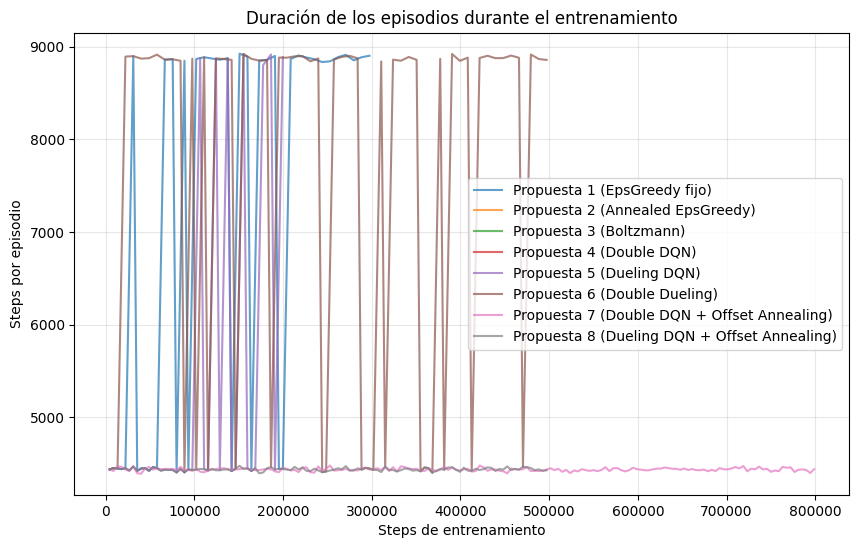

In [13]:
# Gráfica 3: duración media de los episodios (nb_episode_steps) como proxy de
# cuánto tiempo sobrevive / avanza el coche antes de terminar el episodio
plt.figure(figsize=(10, 6))
for label, log in logs.items():
    plt.plot(log['nb_steps'], log['nb_episode_steps'], label=label, alpha=0.7)
plt.xlabel('Steps de entrenamiento')
plt.ylabel('Steps por episodio')
plt.title('Duración de los episodios durante el entrenamiento')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('duracion_episodios.pdf')
plt.show()

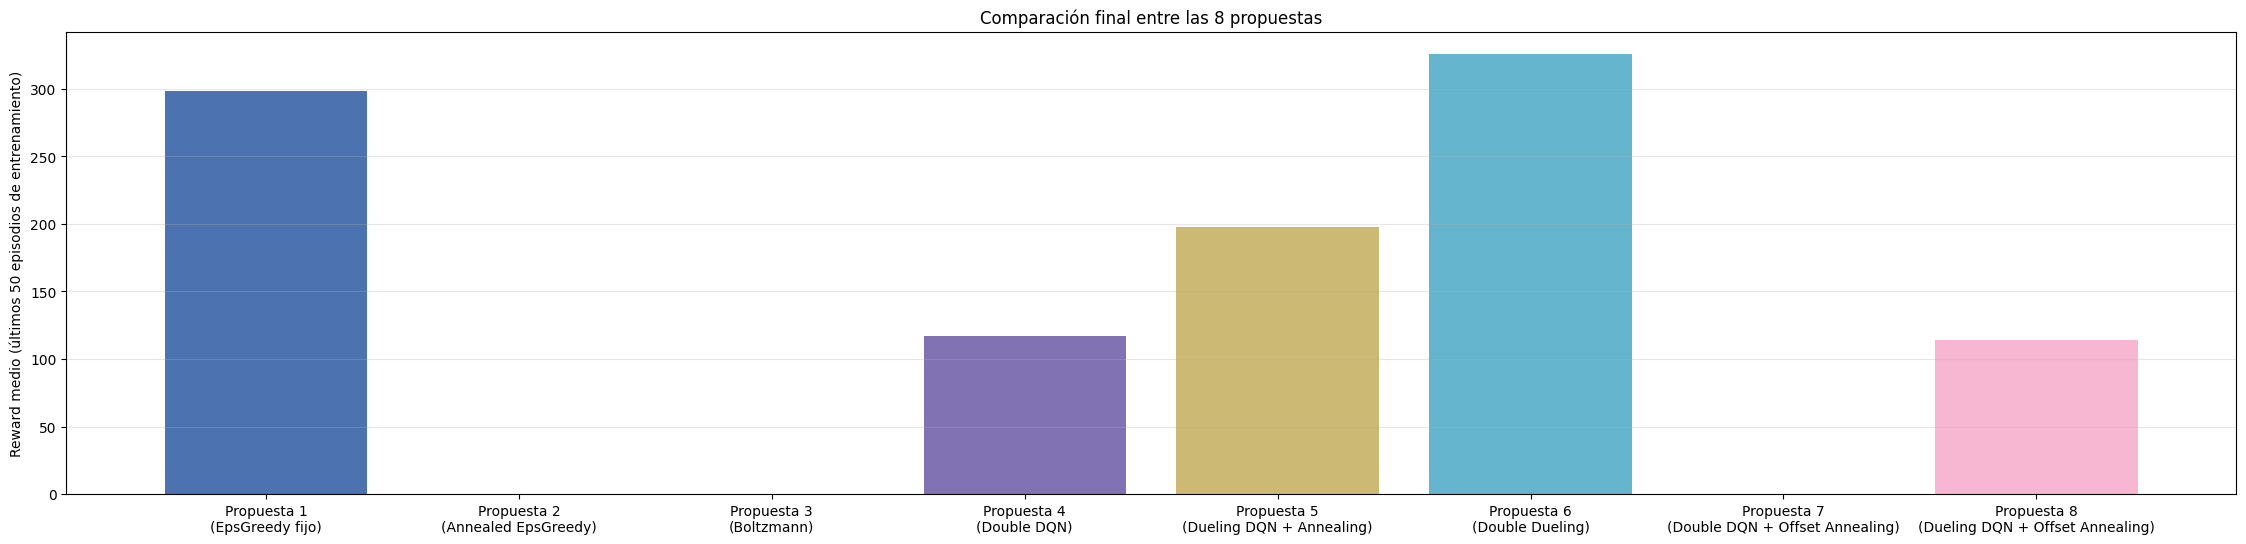

In [14]:
# Gráfica 4
import numpy as np #para poder correr esta celda sin la celda de paquetes
final_means = {
    'Propuesta 1\n(EpsGreedy fijo)': np.mean(log_p1['episode_reward'][-50:]),
    'Propuesta 2\n(Annealed EpsGreedy)': np.mean(log_p2['episode_reward'][-50:]),
    'Propuesta 3\n(Boltzmann)': np.mean(log_p3['episode_reward'][-50:]),
    'Propuesta 4\n(Double DQN)': np.mean(log_p4['episode_reward'][-50:]),
    'Propuesta 5\n(Dueling DQN + Annealing)': np.mean(log_p5['episode_reward'][-50:]),
    'Propuesta 6\n(Double Dueling)': np.mean(log_p6['episode_reward'][-50:]),
    'Propuesta 7\n(Double DQN + Offset Annealing)': np.mean(log_p7['episode_reward'][-50:]),
    'Propuesta 8\n(Dueling DQN + Offset Annealing)': np.mean(log_p8['episode_reward'][-50:]),
}


plt.figure(figsize=(28, 6))
plt.bar(final_means.keys(), final_means.values(),
        color=['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#CCB974', '#64B5CD', '#E377C2', '#F7B6D2'])
plt.ylabel('Reward medio (últimos 50 episodios de entrenamiento)')
plt.title('Comparación final entre las 8 propuestas')
plt.grid(alpha=0.3, axis='y')
plt.savefig('comparacion_final.pdf')
plt.show()